In [1]:
import sys,os
sys.path.append('../../')
os.environ["JAX_PLATFORMS"] = "cpu"
import matplotlib.pyplot as plt
import numpy as np
from utils import makefolder,depths,reduce_list_half_preserve_extremes
from geometry import * 

eps = 1E-7
rcpsize = 14
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0

/home/acevedo/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
modelA = 'deepseek'
# modelA = 'qwen7b'
modelB = modelA
language = 'english'

layers_A = list(range(1,depths[modelA] + 1))
layers_B = list(range(1,depths[modelB] + 1))
layers = np.array(reduce_list_half_preserve_extremes(layers_A),dtype=int)
relative_depths = layers.astype(float) / depths[modelB]

batch_shuffle = 1
n_files = 21
avg_flags = [0,1]
Nbits = 0
match_var = 'matching'
data_vars = ['syn','sem']
zero_activation = 0
center_A_flags = [0,1]
min_token_length = 3
n_tokens = min_token_length

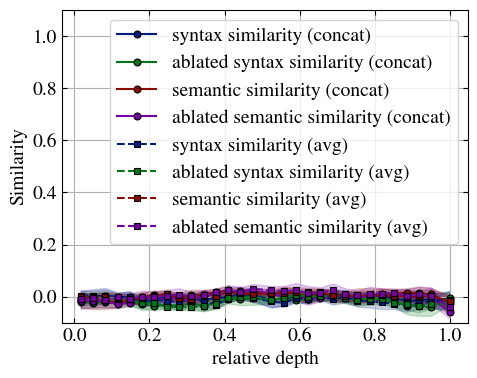

In [3]:
precision = 32
jack_ratio = 0.5
fig, ax = plt.subplots(figsize=(5, 4))

token_offset = 0
for avg_id, avg_tokens in enumerate(avg_flags):
    plot_id = 0
    for data_id, data_var in enumerate(data_vars):
        centers_var = data_var

        for center_A_id, center_A_flag in enumerate(center_A_flags):
            removal_method = 'projection' if center_A_flag != 0 else None
            center_B_flag = center_A_flag
            number_of_languages = 6 if center_A_flag != 0 and data_var == 'sem' else None

            output_folder0 = makefolder(
                base=f'./results/',
                global_centering=0,
                spaces='AB',
                similarity_fn='normalized_L2_distance',
                precision=precision,
                language='english',
                data_var=data_var,
                modelA=modelA,
                modelB=modelB,
                match_var=match_var,
                n_files=n_files,
                min_token_length=min_token_length,
            )

            II_folder = makefolder(
                base=output_folder0,
                centers=centers_var,
                Nbits=Nbits,
                n_tokens=n_tokens,
                avg_tokens=avg_tokens,
                batch_shuffle=batch_shuffle,
                zero_activations=0,
                center_A_flag=center_A_flag,
                center_B_flag=center_B_flag,
                number_of_languages=number_of_languages,
                language_list_permutation=0 if number_of_languages is not None else None,
                removal_method=removal_method,
            )

            inf_imb = 1-np.load(II_folder + f"II_{jack_ratio:.2f}.npy").mean(axis=0)
            std = np.load(II_folder + f"II_jack_std_{jack_ratio:.2f}.npy").mean(axis=0)

            color = colors[plot_id]
            linestyle = '-'

            label = ''

            if data_var == 'sem':
                if center_A_flag == 1: label += 'ablated '
                # label += r'$\mathbf{X}_i \rightarrow \mathbf{P}_i$'
                label += f'semantic similarity'
            if data_var == 'syn':
                if center_A_flag == 1: label += 'ablated '
                # label += r'$\mathbf{X}_i \rightarrow \mathbf{s}_i^0$'
                label += f'syntax similarity'

            # Optional: distinguish avg/concat in legend label
            if avg_tokens:
                label_full = label + ' (avg)'
            else:
                label_full = label + ' (concat)'

            ax.plot(
                relative_depths,
                inf_imb.diagonal(),
                label=label_full,
                linestyle=_linestyles[avg_id],
                color=color,
                marker='o' if avg_id ==0 else 's',                # circular marker
                markersize=5,              # tweakable size
                markerfacecolor=color,     # fill same as line
                markeredgecolor='black',   # cute black border
                markeredgewidth=0.8,       # adjust border thickness
            )

            ax.fill_between(
                relative_depths,
                inf_imb.diagonal() - std.diagonal(),
                inf_imb.diagonal() + std.diagonal(),
                alpha=0.2,
                color=color,
            )
            plot_id += 1



# Formatting for the single axis
ax.set_xlabel('relative depth')
ax.set_ylabel('Similarity')
ax.set_ylim(-0.1, 1.1)

ax.grid()
ax.tick_params(
    top=True, bottom=True, left=True, right=True,
    labeltop=False, labelbottom=True, labelleft=True, labelright=False,
    direction='in'
)

# Single legend (optionally deduplicate labels)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=rcpsize, framealpha=0.8)

# No panel labels anymore

os.makedirs('results/figs', exist_ok=True)
fig.savefig(f'results/figs/batch_shuffling_{modelA}_{removal_method}.pdf', bbox_inches='tight')
plt.show()
